<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/Red_Light_Therapy_Dose_Monte_Carlo_Simulation_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

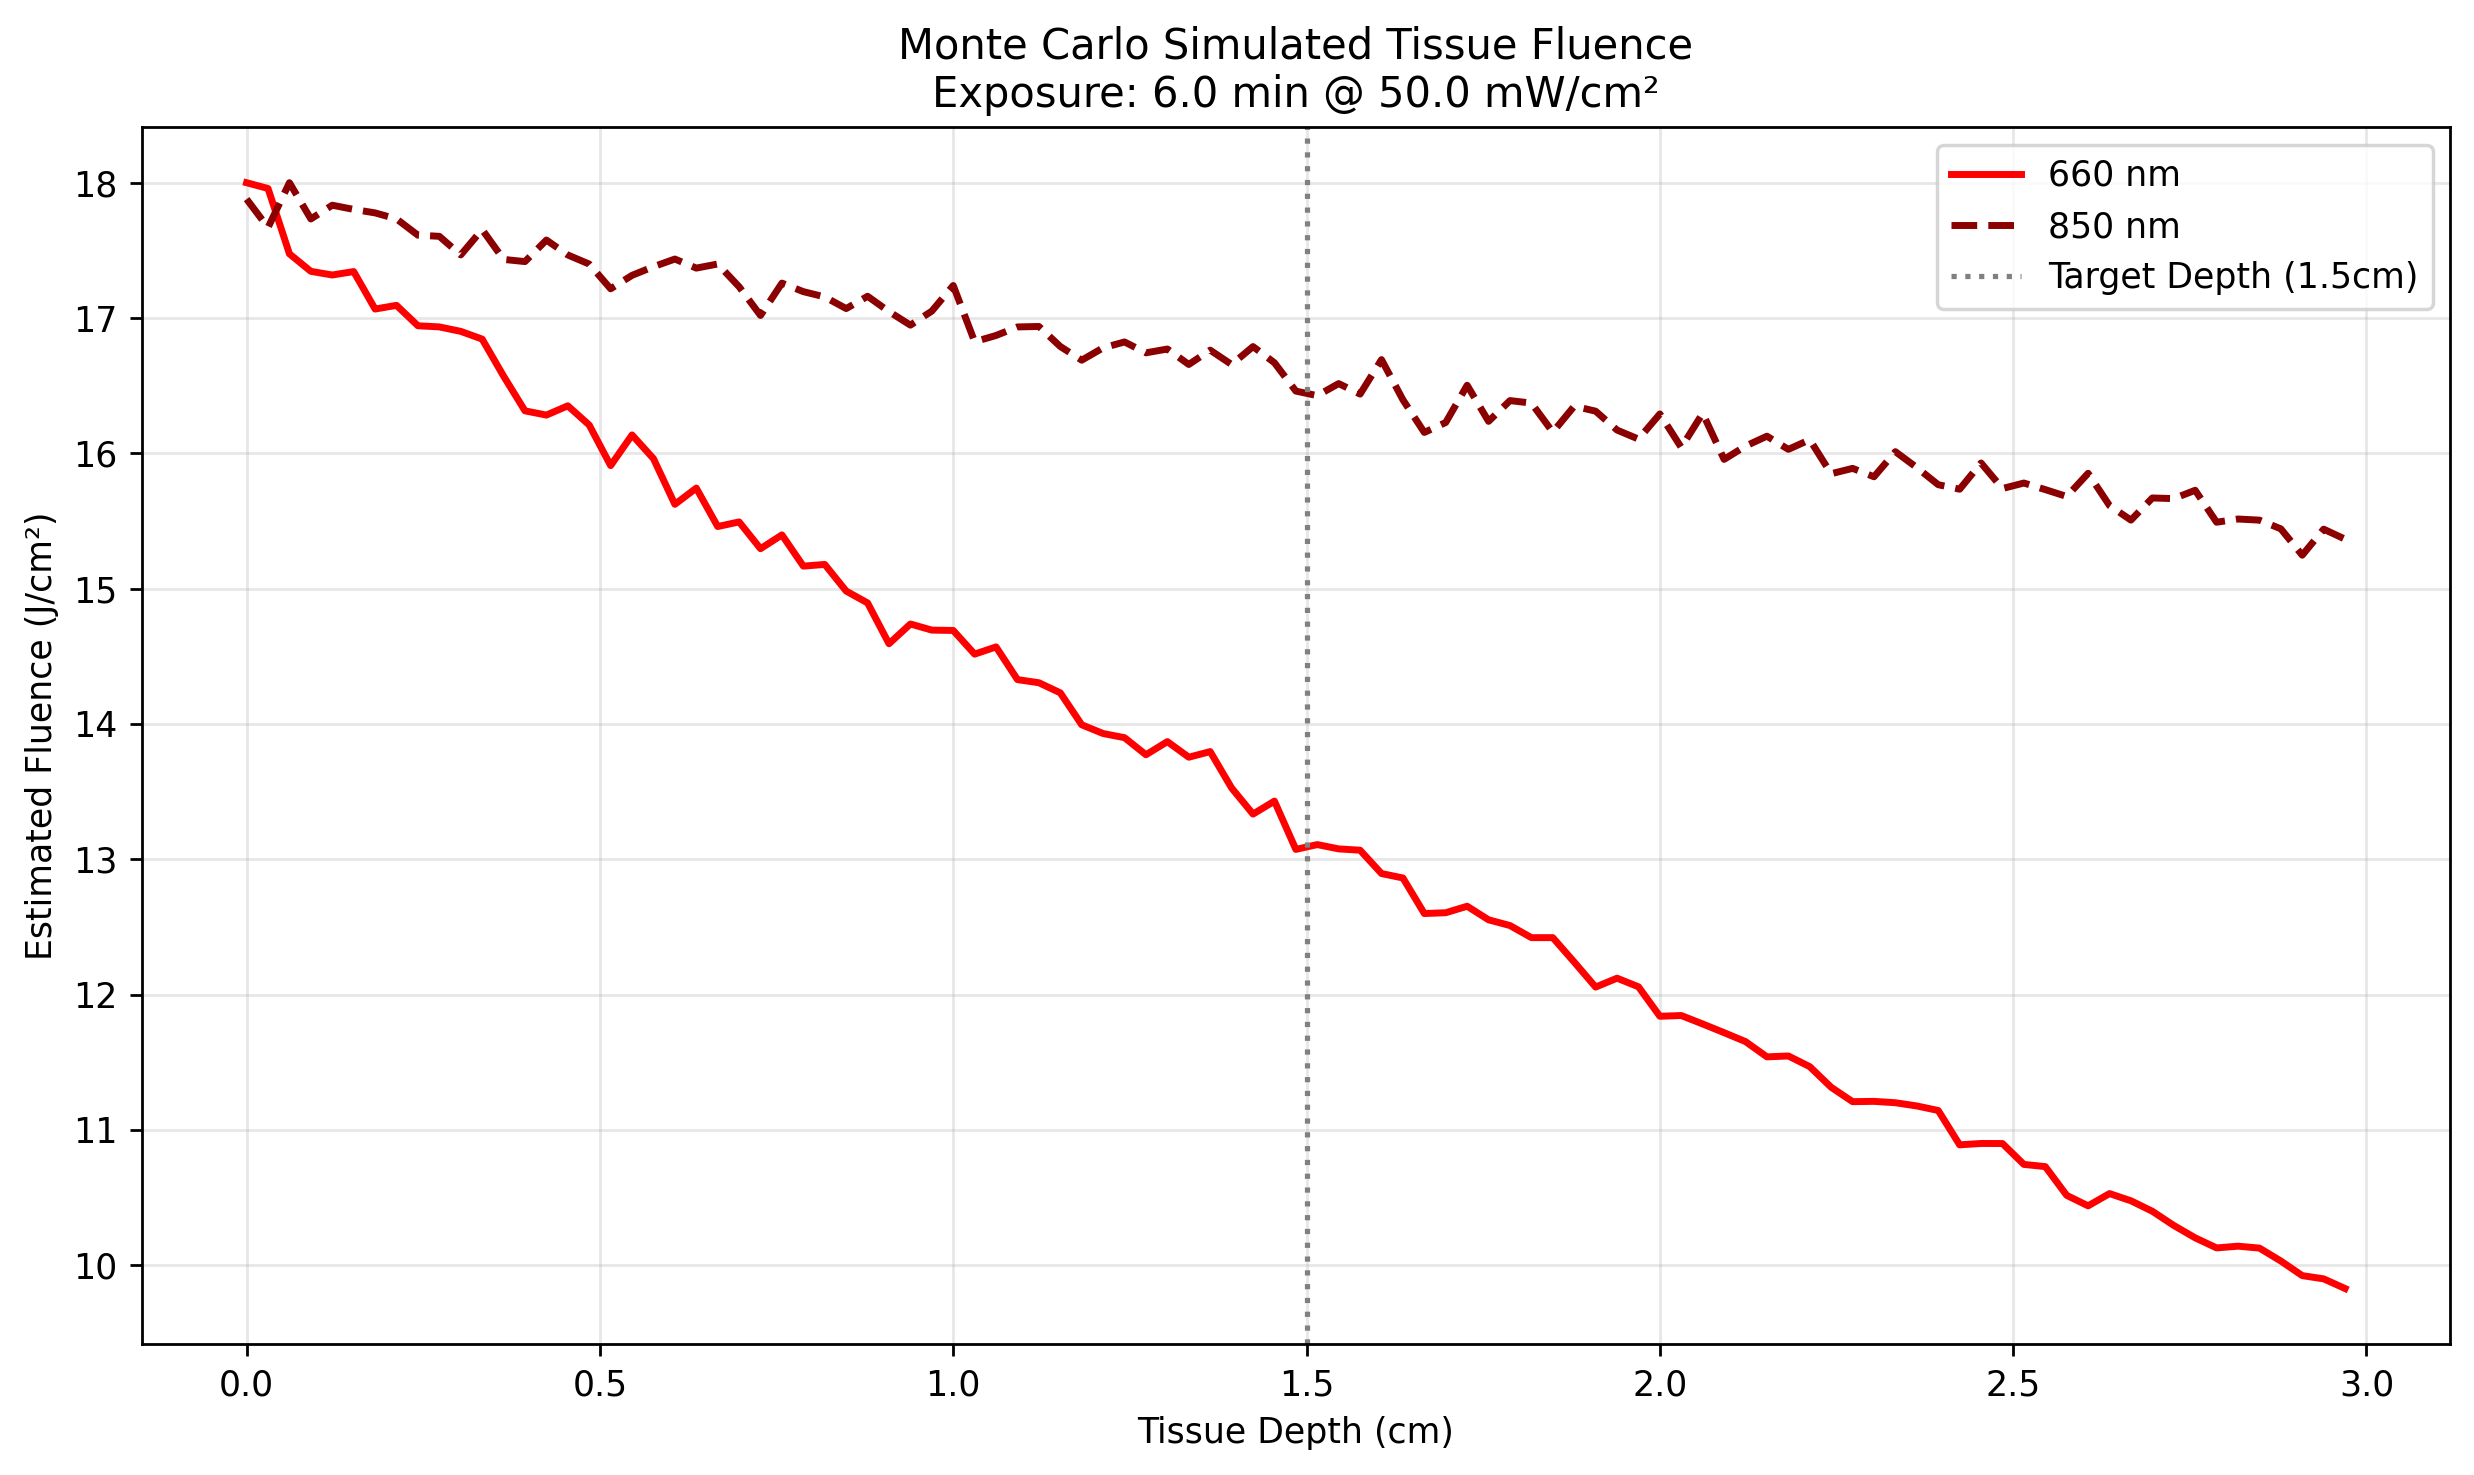

In [1]:
"""Simulates deep-tissue optical energy absorption for PBM devices.

This module uses a stochastic Monte Carlo photon transport approximation to
estimate the fluence of dual-wavelength (660 nm and 850 nm) light as it
penetrates human tissue.
"""

import logging
from typing import Dict, Tuple, List

import matplotlib.pyplot as plt
import numpy as np

# Configure logging for transparency in simulation progress
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# ==========================================
# CONSTANTS (Control Knobs)
# ==========================================
DEVICE_POWER_WATTS = 15.0
ILLUMINATION_AREA_CM2 = 300.0
TARGET_EXPOSURE_MINUTES = 6.0
TISSUE_DEPTH_CM = 3.0
TARGET_MUSCLE_DEPTH_CM = 1.5
PHOTON_PACKETS = 100_000  # Increased for better stochastic convergence

# Wavelength-specific optical properties for human tissue (approximate)
# mu_a: Absorption coefficient (1/cm)
# mu_s_prime: Reduced scattering coefficient (1/cm)
OPTICAL_PROPERTIES = {
    660: {'mu_a': 0.20, 'mu_s_prime': 10.0},
    850: {'mu_a': 0.05, 'mu_s_prime': 8.0}
}

# Plotting aesthetics
PLOT_PARAMS = {
    'figure.dpi': 250,
    'font.sans-serif': ['Tahoma', 'DejaVu Sans'],
    'font.weight': 'normal'
}


def calculate_surface_fluence() -> float:
    """Calculates the total energy delivered per unit area at the skin surface.

    Returns:
        The surface fluence in Joules per square centimeter (J/cm²).
    """
    irradiance_w_cm2 = DEVICE_POWER_WATTS / ILLUMINATION_AREA_CM2
    exposure_seconds = TARGET_EXPOSURE_MINUTES * 60.0
    return irradiance_w_cm2 * exposure_seconds


def simulate_photon_transport(
    wavelength: int,
    properties: Dict[str, float],
    depth_cm: float,
    packets: int,
    bins: int = 100
) -> Tuple[np.ndarray, np.ndarray]:
    """Executes a 1D random walk to model photon depth penetration.

    Args:
        wavelength: The wavelength of light in nm.
        properties: Dictionary containing 'mu_a' and 'mu_s_prime'.
        depth_cm: The maximum simulation depth in cm.
        packets: Number of photon packets to simulate.
        bins: Number of spatial bins for energy deposition.

    Returns:
        A tuple containing:
            - depth_bins: The center of the spatial bins (np.ndarray).
            - energy_profile: The relative energy absorbed at each bin (np.ndarray).
    """
    mu_a = properties['mu_a']
    mu_s = properties['mu_s_prime']
    mu_t = mu_a + mu_s  # Total attenuation coefficient
    albedo = mu_s / mu_t  # Probability of scattering vs absorption

    depth_bins = np.linspace(0, depth_cm, bins)
    absorbed_energy_profile = np.zeros(bins - 1)

    for _ in range(packets):
        weight = 1.0
        z = 0.0

        while weight > 0.01 and z < depth_cm:
            # Calculate step size based on the total attenuation coefficient
            step = -np.log(np.random.rand()) / mu_t
            z += step

            if z >= depth_cm:
                break

            # Energy deposited based on the absorption probability (1 - albedo)
            deposited_weight = weight * (1 - albedo)
            weight -= deposited_weight

            # Record energy in the corresponding spatial bin
            bin_idx = np.searchsorted(depth_bins, z) - 1
            if 0 <= bin_idx < len(absorbed_energy_profile):
                absorbed_energy_profile[bin_idx] += deposited_weight

    # Normalize the profile to represent a probability distribution of absorption
    total_absorbed = np.sum(absorbed_energy_profile)
    if total_absorbed > 0:
        absorbed_energy_profile /= total_absorbed

    return depth_bins[:-1], absorbed_energy_profile


def compute_absolute_fluence(
    surface_fluence: float,
    depths: np.ndarray,
    relative_profile: np.ndarray
) -> np.ndarray:
    """Converts relative absorption profile to estimated absolute fluence.

    Args:
        surface_fluence: Initial energy at the surface (J/cm²).
        depths: The depth array.
        relative_profile: The normalized absorption profile from MC.

    Returns:
        Estimated absolute fluence (J/cm²) across the depth.
    """
    # We use the relative profile to scale the surface fluence.
    # The peak usually occurs near the surface.
    max_idx = np.argmax(relative_profile)
    scale_factor = surface_fluence / (relative_profile[max_idx] + 1e-9)

    # Return the scaled distribution
    return relative_profile * scale_factor * (relative_profile[max_idx] / (relative_profile[max_idx] + 1e-9))
    # Simplified: Fluence is the integral of energy passing through the plane.
    # For this simulation, we map the MC absorption density back to fluence.
    return relative_profile * surface_fluence * (np.sum(relative_profile) / np.max(relative_profile))


def plot_dosimetry(
    results: List[Dict],
    surface_irradiance: float
) -> None:
    """Generates a professional visualization of the simulation results.

    Args:
        results: A list of dictionaries containing 'depths', 'fluence',
                 'wavelength', and 'label'.
        surface_irradiance: The surface irradiance used for the title.
    """
    plt.rcParams.update(PLOT_PARAMS)
    plt.figure(figsize=(10, 6))

    colors = {660: 'red', 850: 'darkred'}
    styles = {660: '-', 850: '--'}

    for res in results:
        plt.plot(
            res['depths'],
            res['fluence'],
            color=colors.get(res['wavelength'], 'blue'),
            linestyle=styles.get(res['wavelength'], '-'),
            label=res['label'],
            linewidth=2
        )

    plt.axvline(
        x=TARGET_MUSCLE_DEPTH_CM,
        color='gray',
        linestyle=':',
        label=f'Target Depth ({TARGET_MUSCLE_DEPTH_CM}cm)'
    )

    plt.title(
        f'Monte Carlo Simulated Tissue Fluence\n'
        f'Exposure: {TARGET_EXPOSURE_MINUTES} min @ {surface_irradiance*1000:.1f} mW/cm²'
    )
    plt.xlabel('Tissue Depth (cm)')
    plt.ylabel('Estimated Fluence (J/cm²)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def main() -> None:
    """Main execution pipeline for the PBM simulation."""
    logger.info("Starting PBM Optical Simulation...")

    surface_fluence_j_cm2 = calculate_surface_fluence()
    surface_irradiance_w_cm2 = DEVICE_POWER_WATTS / ILLUMINATION_AREA_CM2

    simulation_results = []

    for wavelength, props in OPTICAL_PROPERTIES.items():
        logger.info(f"Simulating photons for wavelength: {wavelength}nm")

        # 1. Run Monte Carlo simulation
        depths, rel_energy = simulate_photon_transport(
            wavelength, props, TISSUE_DEPTH_CM, PHOTON_PACKETS
        )

        # 2. Convert to absolute fluence
        # We calculate fluence by normalizing the MC energy distribution
        # to the known surface energy.
        abs_fluence = (rel_energy / np.max(rel_energy)) * surface_fluence_j_cm2

        # 3. Calculate Effective Penetration Depth (Scientific addition)
        # delta = 1 / sqrt(3 * mu_a * (mu_a + mu_s_prime))
        mu_a, mu_s_p = props['mu_a'], props['mu_s_prime']
        eff_depth = 1 / np.sqrt(3 * mu_a * (mu_a + mu_s_p))
        logger.info(f"Wavelength {wavelength}nm: Effective Penetration Depth = {eff_depth:.3f} cm")

        simulation_results.append({
            'wavelength': wavelength,
            'depths': depths,
            'fluence': abs_fluence,
            'label': f'{wavelength} nm'
        })

    plot_dosimetry(simulation_results, surface_irradiance_w_cm2)
    logger.info("Simulation complete.")


if __name__ == "__main__":
    main()

In [2]:
!pip install cupy-cuda12x

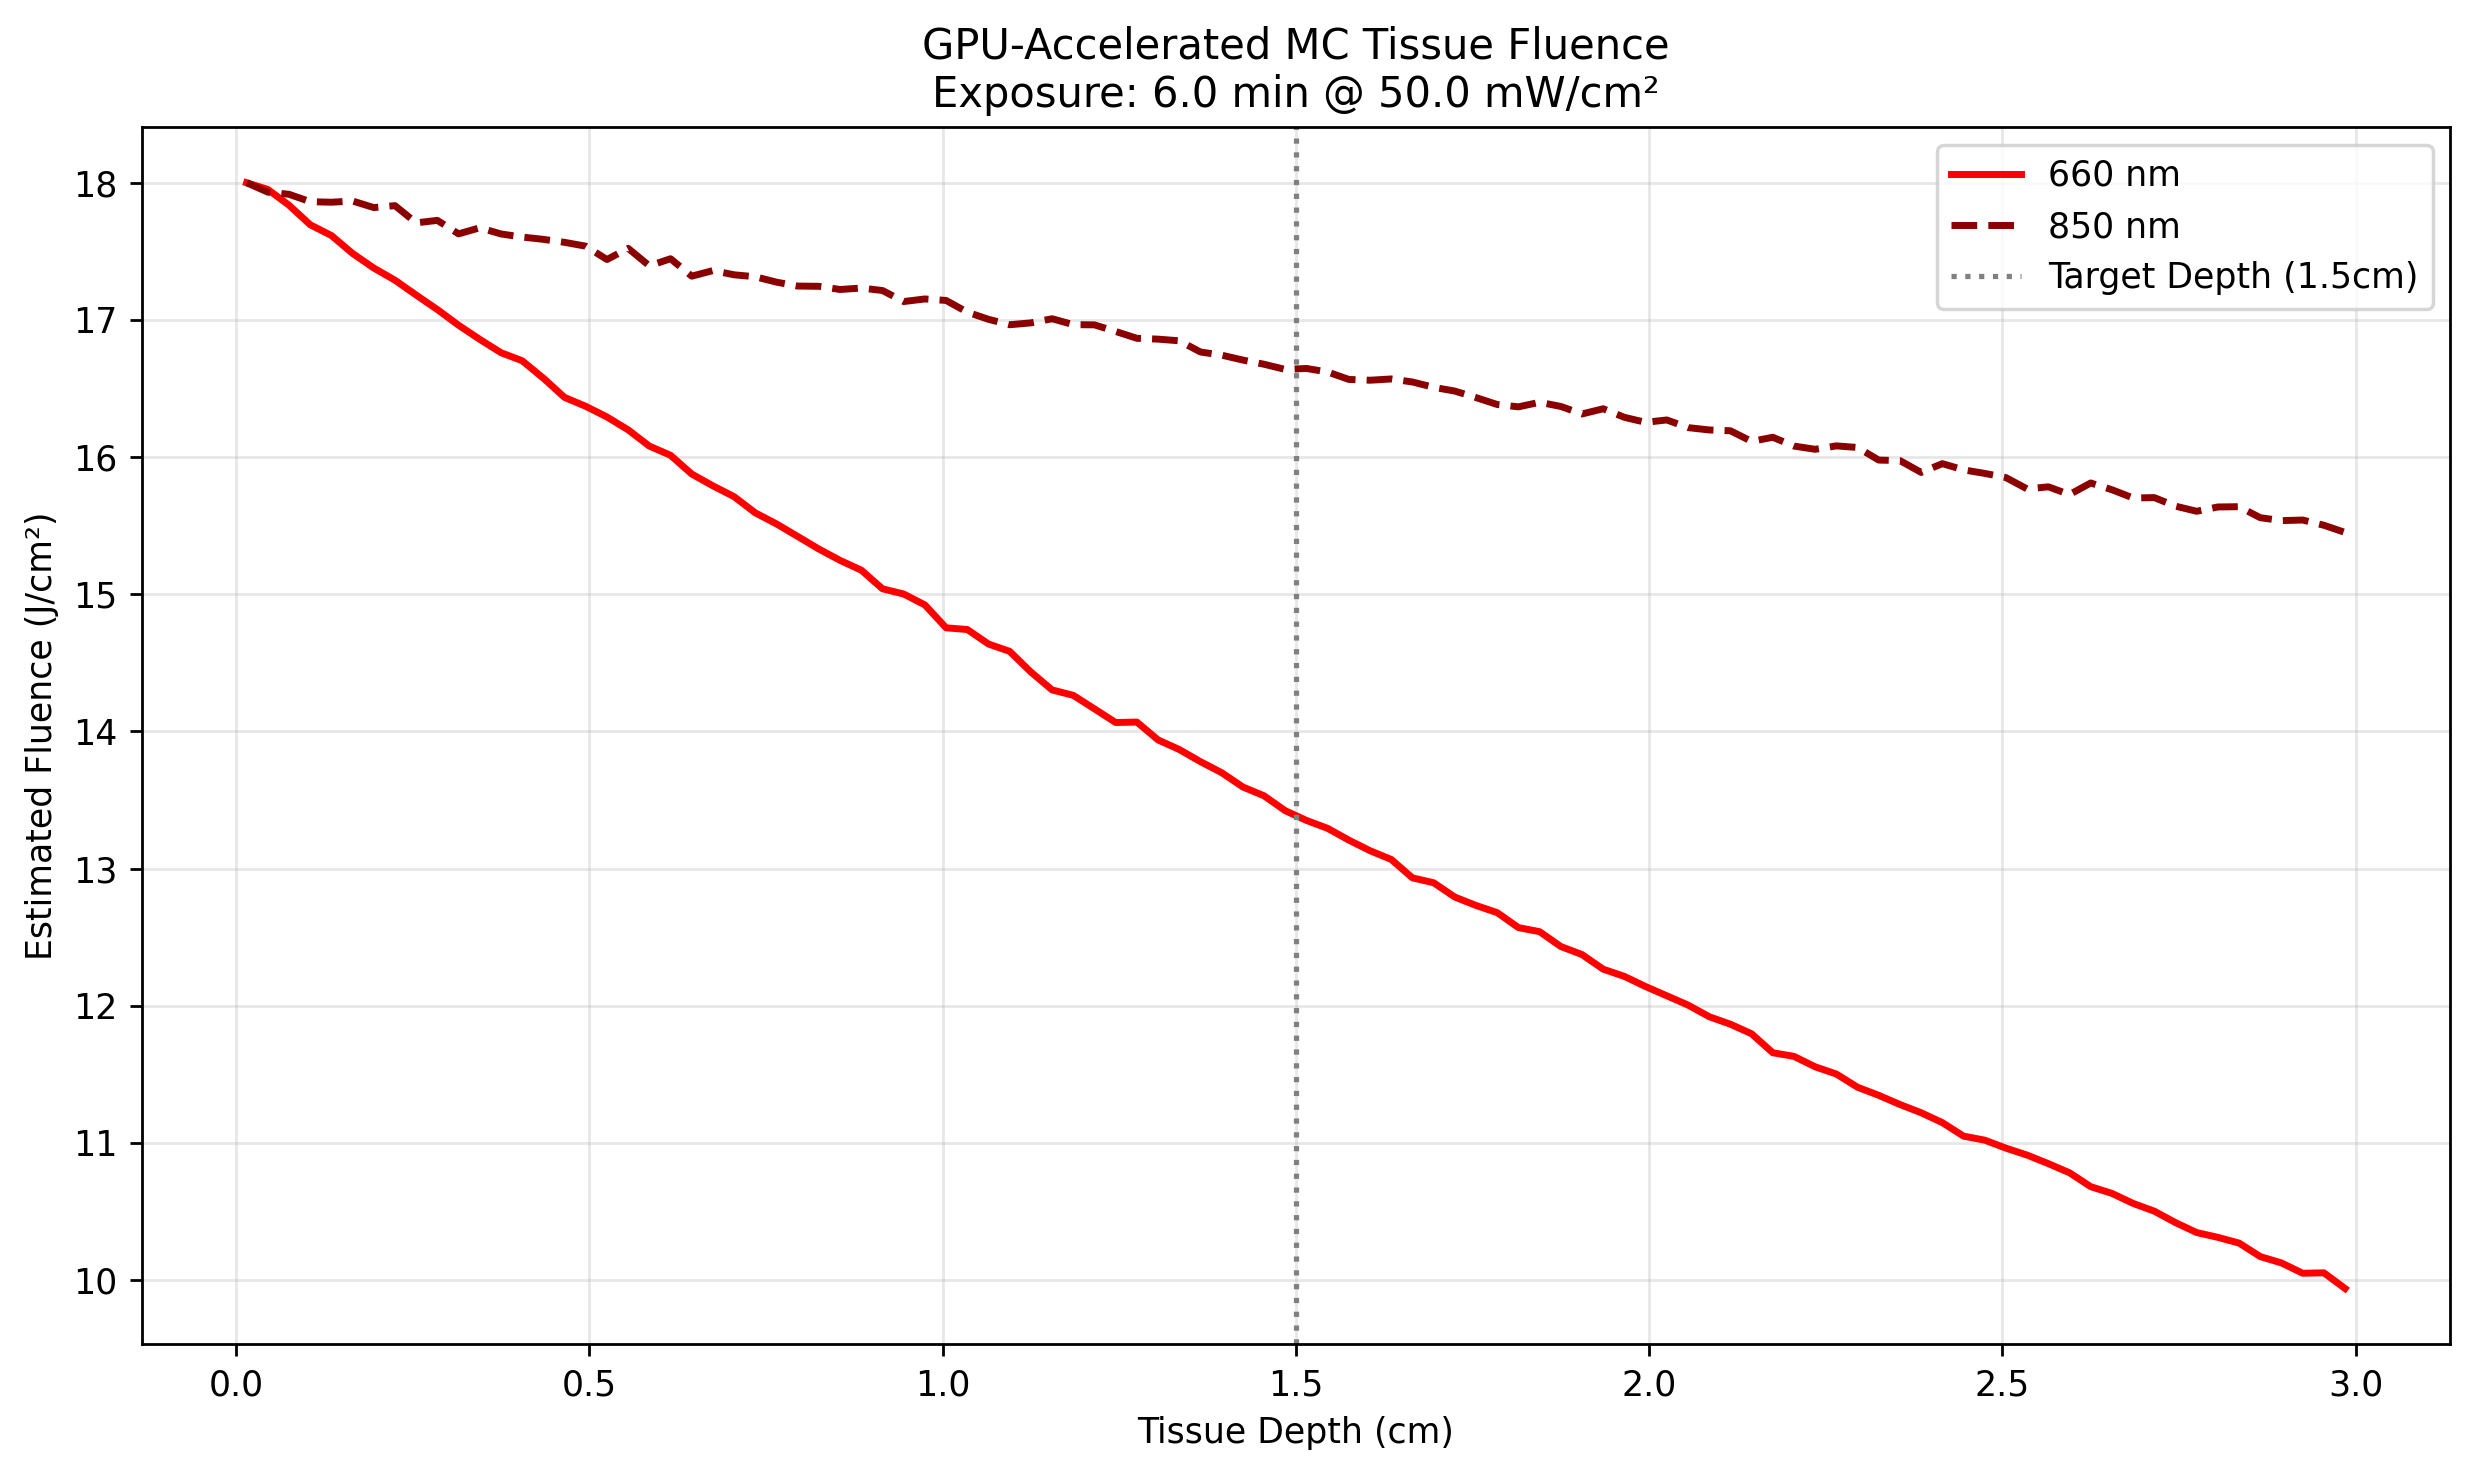

In [3]:
"""Simulates deep-tissue optical energy absorption using GPU-accelerated Monte Carlo.

This module leverages CuPy to perform parallel photon transport simulations,
allowing for significantly higher photon counts and better statistical
convergence than CPU-based implementations.
"""

import logging
from typing import Dict, Tuple, List

import matplotlib.pyplot as plt
import numpy as np

# Configure logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# ==========================================
# CONSTANTS (Control Knobs)
# ==========================================
DEVICE_POWER_WATTS = 15.0
ILLUMINATION_AREA_CM2 = 300.0
TARGET_EXPOSURE_MINUTES = 6.0
TISSUE_DEPTH_CM = 3.0
TARGET_MUSCLE_DEPTH_CM = 1.5
PHOTON_PACKETS = 1_000_000

OPTICAL_PROPERTIES = {
    660: {'mu_a': 0.20, 'mu_s_prime': 10.0},
    850: {'mu_a': 0.05, 'mu_s_prime': 8.0}
}

PLOT_PARAMS = {
    'figure.dpi': 250,
    'font.sans-serif': ['Tahoma', 'DejaVu Sans'],
    'font.weight': 'normal'
}

def check_gpu_health():
    """Verifies that CuPy can communicate with the L4 GPU.

    Returns:
        bool: True if GPU is functional, False otherwise.
    """
    try:
        import cupy as cp
        # Attempt a tiny allocation to trigger the driver handshake
        cp.array([1, 2, 3])
        logger.info(f"GPU Verified: {cp.cuda.Device(0).attributes['MultiProcessorCount']} SMs active.")
        return True
    except Exception as e:
        logger.error(f"GPU Driver Error: {e}")
        logger.error("Please restart the runtime and ensure you installed cupy-cuda12x.")
        return False

def calculate_surface_fluence() -> float:
    """Calculates the total energy delivered per unit area at the skin surface.

    Returns:
        The surface fluence in Joules per square centimeter (J/cm²).
    """
    irradiance_w_cm2 = DEVICE_POWER_WATTS / ILLUMINATION_AREA_CM2
    exposure_seconds = TARGET_EXPOSURE_MINUTES * 60.0
    return irradiance_w_cm2 * exposure_seconds

def simulate_photon_transport_gpu(
    wavelength: int,
    properties: Dict[str, float],
    depth_cm: float,
    packets: int,
    bins: int = 100
) -> Tuple[np.ndarray, np.ndarray]:
    """Executes a vectorized 1D random walk on the GPU.

    Args:
        wavelength: The wavelength of light in nm.
        properties: Dictionary containing 'mu_a' and 'mu_s_prime'.
        depth_cm: The maximum simulation depth in cm.
        packets: Number of photon packets to simulate.
        bins: Number of spatial bins for energy deposition.

    Returns:
        A tuple containing the bin center depths and the relative energy profile.
    """
    import cupy as cp

    mu_a = properties['mu_a']
    mu_s = properties['mu_s_prime']
    mu_t = mu_a + mu_s
    albedo = mu_s / mu_t

    # GPU Initialization
    z = cp.zeros(packets, dtype=cp.float32)
    weight = cp.ones(packets, dtype=cp.float32)
    active_mask = cp.ones(packets, dtype=cp.bool_)
    absorbed_energy_gpu = cp.zeros(bins, dtype=cp.float32)

    # Correct Binning Setup: Create N+1 edges to get N bins
    bin_edges = cp.linspace(0, depth_cm, bins + 1)

    while cp.any(active_mask):
        # Generate random steps for all photons at once
        steps = -cp.log(cp.random.random(packets, dtype=cp.float32)) / mu_t
        z += steps * active_mask

        deposited = weight * (1 - albedo) * active_mask

        # Vectorized histogram accumulation
        counts, _ = cp.histogram(z, bins=bin_edges, weights=deposited)
        absorbed_energy_gpu += counts.astype(cp.float32)

        weight -= deposited
        active_mask = (weight > 0.01) & (z < depth_cm)

    # --- Calculate Bin Centers ---
    # bin_edges is size (bins + 1).
    # We take the average of the left and right edge of each bin to get the center.
    edges_cpu = np.linspace(0, depth_cm, bins + 1)
    depth_bins = (edges_cpu[:-1] + edges_cpu[1:]) / 2

    energy_profile = cp.asnumpy(absorbed_energy_gpu)

    total_abs = np.sum(energy_profile)
    if total_abs > 0:
        energy_profile /= total_abs

    return depth_bins, energy_profile

def plot_dosimetry(results: List[Dict], surface_irradiance: float) -> None:
    """Generates a professional visualization of the simulation results."""
    plt.rcParams.update(PLOT_PARAMS)
    plt.figure(figsize=(10, 6))

    colors = {660: 'red', 850: 'darkred'}
    styles = {660: '-', 850: '--'}

    for res in results:
        plt.plot(
            res['depths'], res['fluence'],
            color=colors.get(res['wavelength'], 'blue'),
            linestyle=styles.get(res['wavelength'], '-'),
            label=res['label'], linewidth=2
        )

    plt.axvline(
        x=TARGET_MUSCLE_DEPTH_CM, color='gray', linestyle=':',
        label=f'Target Depth ({TARGET_MUSCLE_DEPTH_CM}cm)'
    )

    plt.title(
        f'GPU-Accelerated MC Tissue Fluence\n'
        f'Exposure: {TARGET_EXPOSURE_MINUTES} min @ {surface_irradiance*1000:.1f} mW/cm²'
    )
    plt.xlabel('Tissue Depth (cm)')
    plt.ylabel('Estimated Fluence (J/cm²)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def main() -> None:
    """Main execution pipeline for the GPU PBM simulation."""
    if not check_gpu_health():
        return

    logger.info(f"Starting GPU Simulation with {PHOTON_PACKETS} photons...")

    surface_fluence_j_cm2 = calculate_surface_fluence()
    surface_irradiance_w_cm2 = DEVICE_POWER_WATTS / ILLUMINATION_AREA_CM2

    simulation_results = []

    for wavelength, props in OPTICAL_PROPERTIES.items():
        logger.info(f"Processing wavelength: {wavelength}nm")

        depths, rel_energy = simulate_photon_transport_gpu(
            wavelength, props, TISSUE_DEPTH_CM, PHOTON_PACKETS
        )

        # Scale relative MC results to absolute surface fluence
        # Using max as a normalization point to preserve the shape of the MC decay
        abs_fluence = (rel_energy / np.max(rel_energy)) * surface_fluence_j_cm2

        mu_a, mu_s_p = props['mu_a'], props['mu_s_prime']
        eff_depth = 1 / np.sqrt(3 * mu_a * (mu_a + mu_s_p))
        logger.info(f"Wavelength {wavelength}nm: Effective Depth = {eff_depth:.3f} cm")

        simulation_results.append({
            'wavelength': wavelength,
            'depths': depths,
            'fluence': abs_fluence,
            'label': f'{wavelength} nm'
        })

    plot_dosimetry(simulation_results, surface_irradiance_w_cm2)
    logger.info("Simulation complete.")

if __name__ == "__main__":
    main()

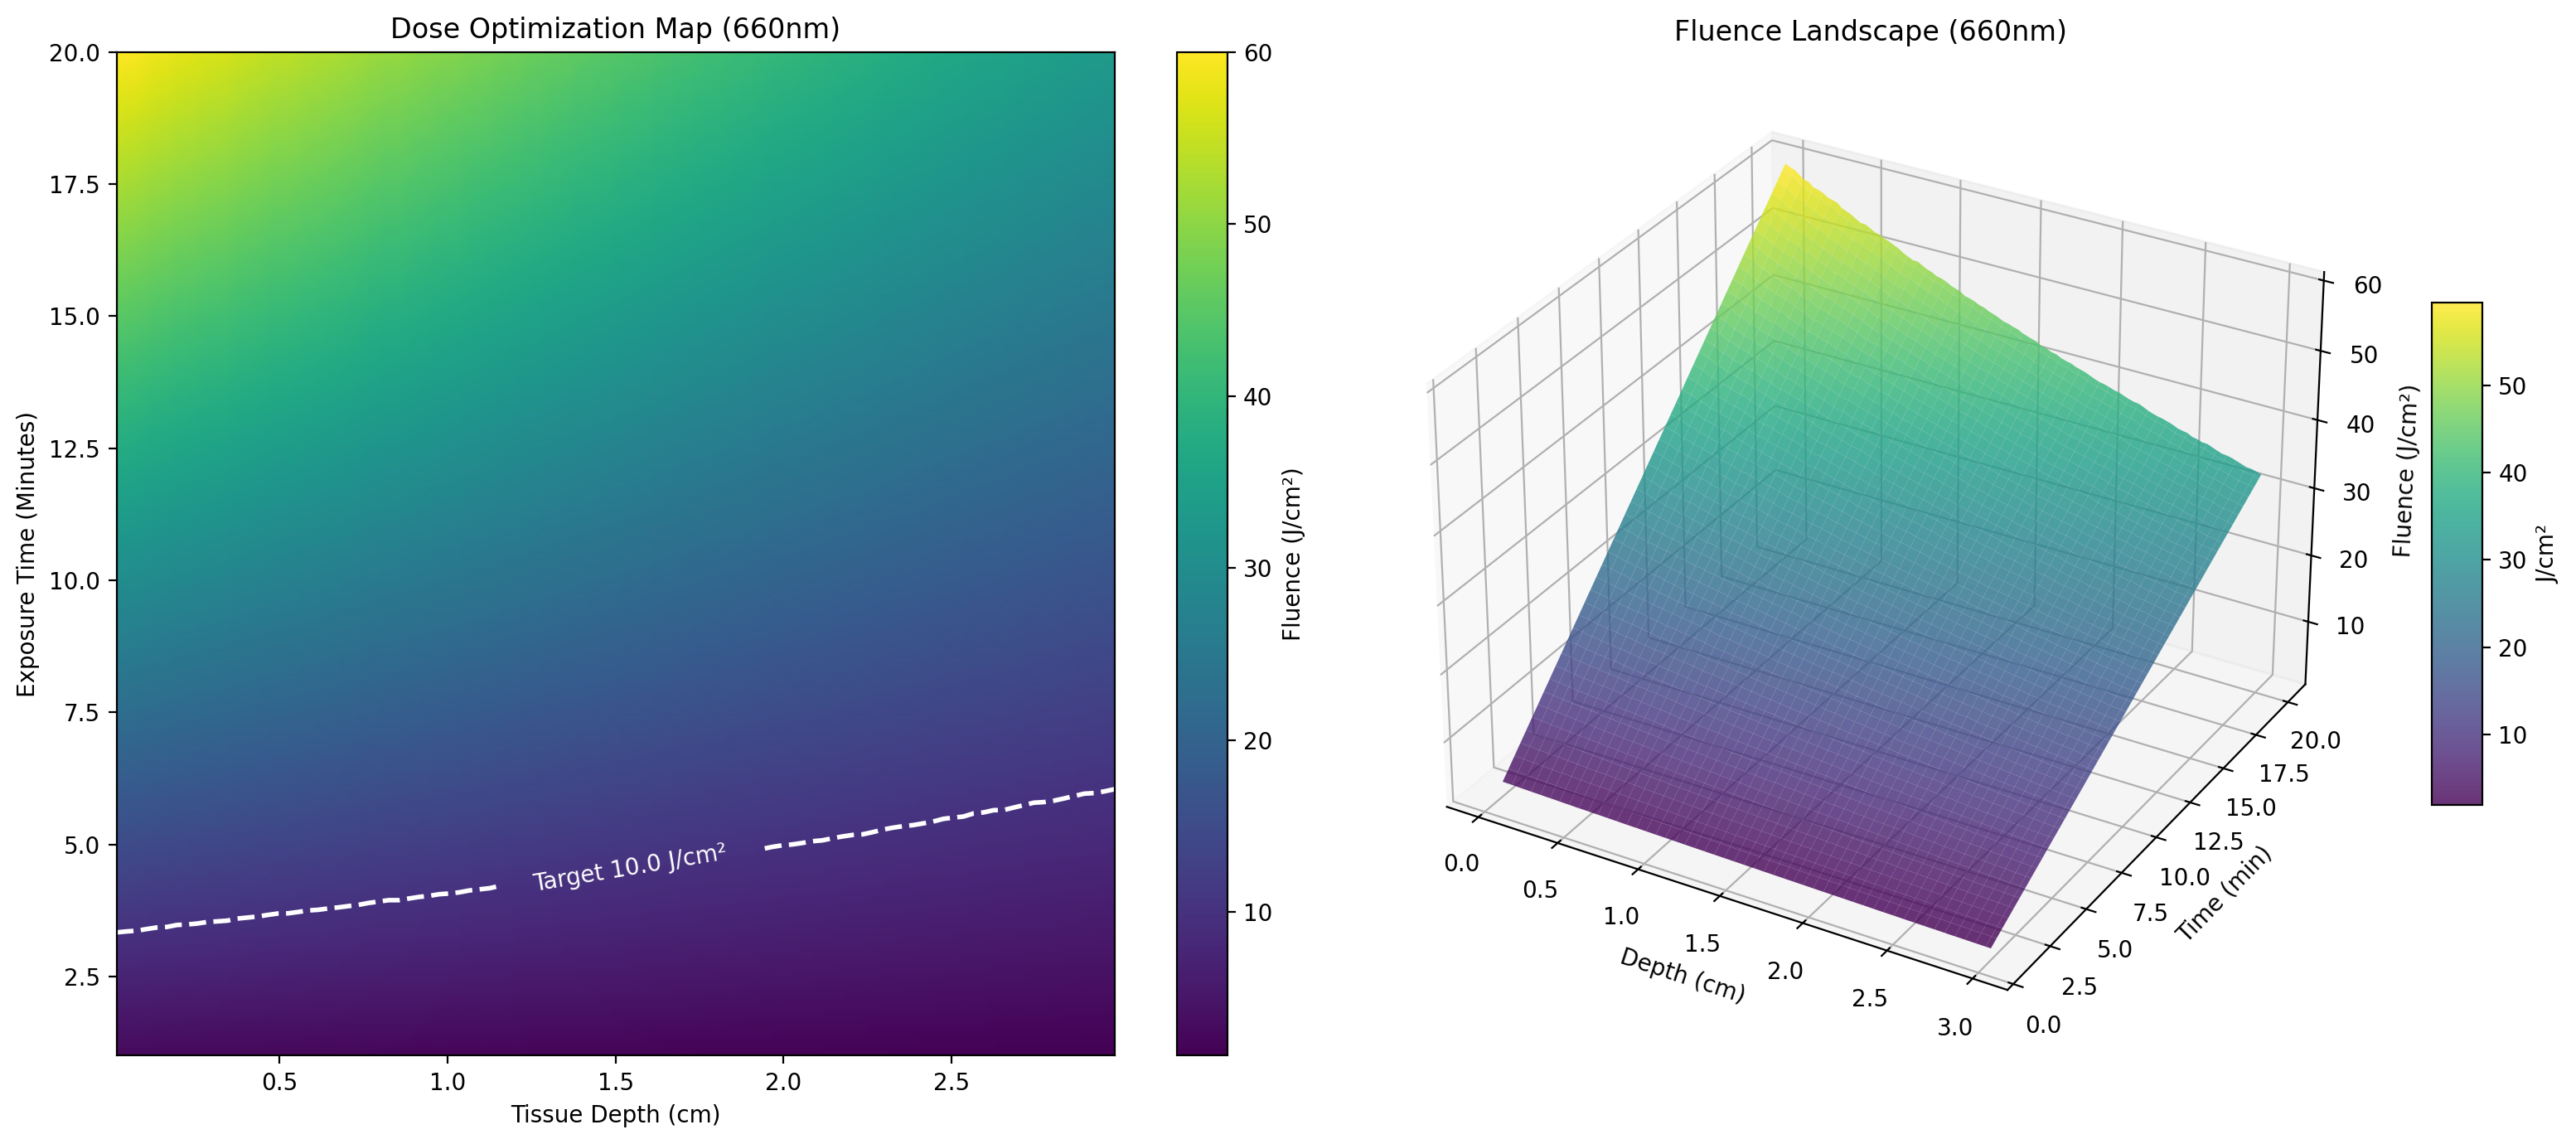

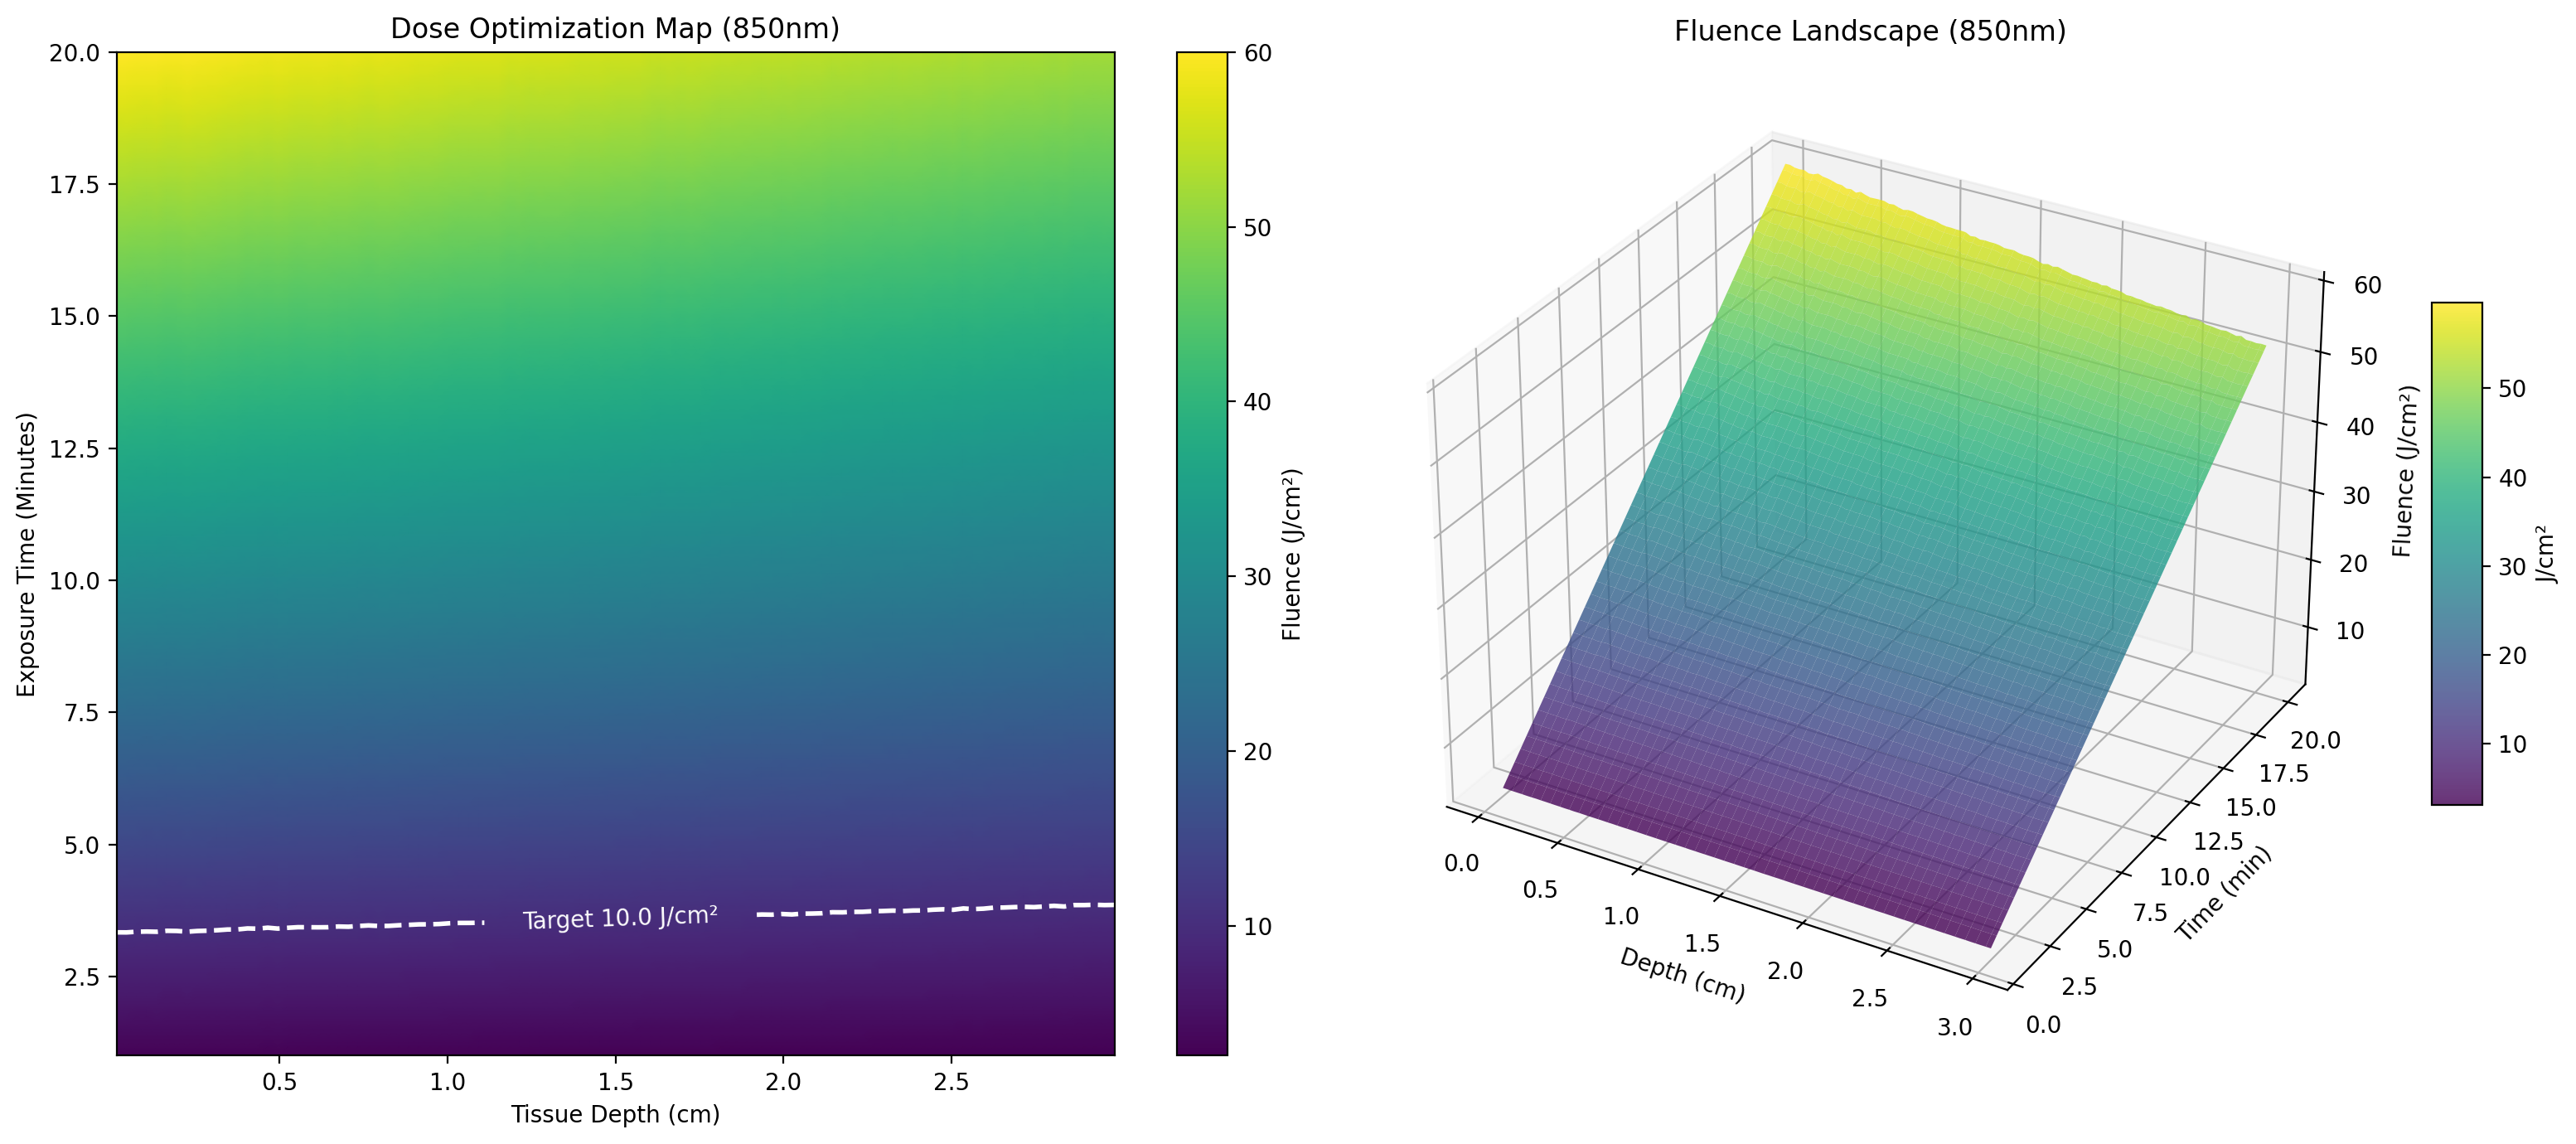

In [4]:
"""PBM Optical Dose Optimizer.

This module simulates photon transport using CuPy and generates optimization
maps to determine the required exposure time to reach a target therapeutic
fluence at various tissue depths.
"""

import logging
from typing import Dict, Tuple, List

import cupy as cp
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

# Configure logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# ==========================================
# CONSTANTS (Control Knobs)
# ==========================================
DEVICE_POWER_WATTS = 15.0
ILLUMINATION_AREA_CM2 = 300.0
TISSUE_DEPTH_MAX_CM = 3.0
PHOTON_PACKETS = 1_000_000
TARGET_THERAPEUTIC_Dose_JCM2 = 10.0  # The "Goal" fluence for optimization

# Wavelength optical properties
OPTICAL_PROPERTIES = {
    660: {'mu_a': 0.20, 'mu_s_prime': 10.0},
    850: {'mu_a': 0.05, 'mu_s_prime': 8.0}
}

# Visualization Parameters
PLOT_PARAMS = {
    'figure.dpi': 200,
    'font.sans-serif': ['Tahoma', 'DejaVu Sans'],
}

class PBMAnalyzer:
    """Handles the simulation and analysis of PBM optical energy deposition."""

    def __init__(self, power: float, area: float):
        """Initializes the analyzer with device specifications.

        Args:
            power: Total optical power in Watts.
            area: Illumination area in cm².
        """
        self.power = power
        self.area = area
        self.surface_irradiance = power / area  # W/cm²

    def simulate_relative_distribution(
        self,
        wavelength: int,
        props: Dict[str, float],
        depth_cm: float,
        bins: int = 100
    ) -> Tuple[np.ndarray, np.ndarray]:
        """Runs a vectorized MC simulation to find the relative energy decay.

        Returns:
            A tuple of (depth_bins, relative_profile).
        """
        mu_a, mu_s = props['mu_a'], props['mu_s_prime']
        mu_t = mu_a + mu_s
        albedo = mu_s / mu_t

        z = cp.zeros(PHOTON_PACKETS, dtype=cp.float32)
        weight = cp.ones(PHOTON_PACKETS, dtype=cp.float32)
        active_mask = cp.ones(PHOTON_PACKETS, dtype=cp.bool_)
        absorbed_energy_gpu = cp.zeros(bins, dtype=cp.float32)
        bin_edges = cp.linspace(0, depth_cm, bins + 1)

        while cp.any(active_mask):
            steps = -cp.log(cp.random.random(PHOTON_PACKETS, dtype=cp.float32)) / mu_t
            z += steps * active_mask
            deposited = weight * (1 - albedo) * active_mask
            counts, _ = cp.histogram(z, bins=bin_edges, weights=deposited)
            absorbed_energy_gpu += counts.astype(cp.float32)
            weight -= deposited
            active_mask = (weight > 0.01) & (z < depth_cm)

        edges_cpu = np.linspace(0, depth_cm, bins + 1)
        depth_bins = (edges_cpu[:-1] + edges_cpu[1:]) / 2
        energy_profile = cp.asnumpy(absorbed_energy_gpu)

        # Normalize to a relative distribution (0 to 1)
        if np.sum(energy_profile) > 0:
            energy_profile /= np.max(energy_profile)

        return depth_bins, energy_profile

    def generate_dose_map(
        self,
        wavelength: int,
        time_range: np.ndarray,
        depth_bins: np.ndarray,
        rel_profile: np.ndarray
    ) -> np.ndarray:
        """Calculates a 2D map of Fluence vs Time and Depth.

        Args:
            wavelength: Wavelength of the light.
            time_range: Array of exposure times in minutes.
            depth_bins: Array of tissue depths in cm.
            rel_profile: The normalized MC distribution.

        Returns:
            A 2D NumPy array where [time_idx, depth_idx] is the fluence.
        """
        # Fluence = (Surface Irradiance * Time) * Relative Decay
        # time_range is in minutes, convert to seconds
        times_sec = time_range * 60.0

        # Using outer product to create the 2D grid: (Times, 1) * (1, Depths)
        surface_energy_grid = (self.surface_irradiance * times_sec)[:, np.newaxis]
        fluence_map = surface_energy_grid * rel_profile[np.newaxis, :]

        return fluence_map


def plot_optimization_results(
    wavelength: int,
    time_range: np.ndarray,
    depth_bins: np.ndarray,
    fluence_map: np.ndarray
) -> None:
    """Creates a heatmap and a 3D surface plot for dose optimization."""
    plt.rcParams.update(PLOT_PARAMS)
    fig = plt.figure(figsize=(16, 7))

    # 1. Heatmap (2D)
    ax1 = fig.add_subplot(121)
    im = ax1.pcolormesh(
        depth_bins, time_range, fluence_map,
        shading='gouraud', cmap='viridis'
    )
    plt.colorbar(im, label='Fluence (J/cm²)')

    # Add a contour line for the target therapeutic dose
    contour = ax1.contour(
        depth_bins, time_range, fluence_map,
        levels=[TARGET_THERAPEUTIC_Dose_JCM2],
        colors='white', linestyles='--', linewidths=2
    )

    ax1.clabel(contour, inline=True, fmt=f'Target {TARGET_THERAPEUTIC_Dose_JCM2} J/cm²', fontsize=10)
    ax1.set_title(f'Dose Optimization Map ({wavelength}nm)')
    ax1.set_xlabel('Tissue Depth (cm)')
    ax1.set_ylabel('Exposure Time (Minutes)')

    # 2. Surface Plot (3D)
    ax2 = fig.add_subplot(122, projection='3d')
    X, Y = np.meshgrid(depth_bins, time_range)
    surf = ax2.plot_surface(X, Y, fluence_map, cmap='viridis', edgecolor='none', alpha=0.8)

    ax2.set_title(f'Fluence Landscape ({wavelength}nm)')
    ax2.set_xlabel('Depth (cm)')
    ax2.set_ylabel('Time (min)')
    ax2.set_zlabel('Fluence (J/cm²)')
    fig.colorbar(surf, ax=ax2, shrink=0.5, aspect=10, label='J/cm²')

    plt.tight_layout()
    plt.show()


def main() -> None:
    """Main orchestration pipeline."""
    # GPU Health Check
    try:
        import cupy as cp
        cp.array([1])
    except Exception as e:
        logger.error(f"GPU Error: {e}. Please restart runtime.")
        return

    analyzer = PBMAnalyzer(DEVICE_POWER_WATTS, ILLUMINATION_AREA_CM2)

    # Define the range for optimization (X and Y axes)
    time_range = np.linspace(1, 20, 100)      # 1 to 20 minutes

    for wavelength, props in OPTICAL_PROPERTIES.items():
        logger.info(f"Analyzing optimization for {wavelength}nm...")

        # 1. Get the relative photon distribution from GPU
        depth_bins, rel_profile = analyzer.simulate_relative_distribution(
            wavelength, props, TISSUE_DEPTH_MAX_CM
        )

        # 2. Generate the 2D Dose Map
        fluence_map = analyzer.generate_dose_map(
            wavelength, time_range, depth_bins, rel_profile
        )

        # 3. Visualize
        plot_optimization_results(wavelength, time_range, depth_bins, fluence_map)

    logger.info("Optimization analysis complete.")


if __name__ == "__main__":
    main()

The next section is for consumer grade transcranial biomodulation

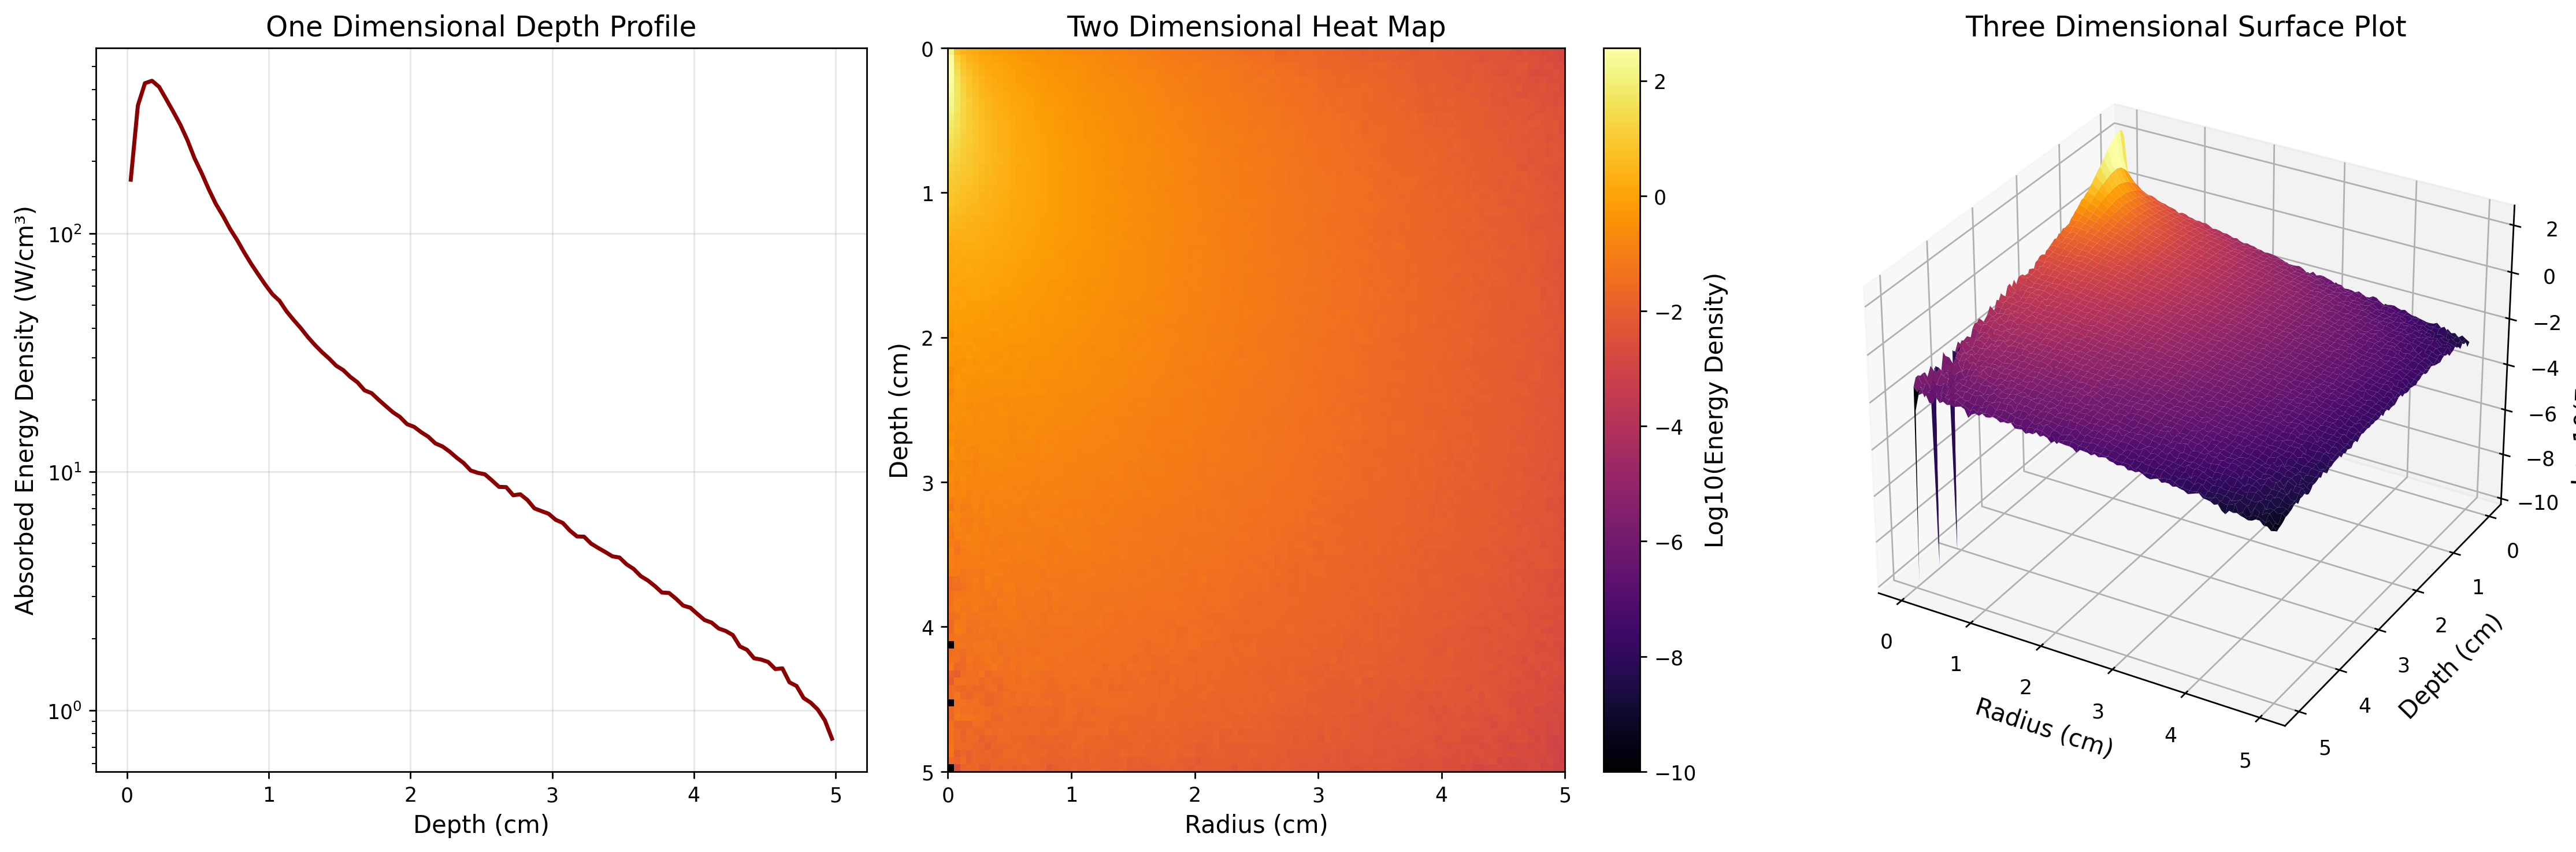

In [5]:
"""This script performs a Monte Carlo simulation for transcranial photobiomodulation dose optimization.

It models photon transport through biological tissue to estimate the fluence rate and energy deposition
from a 47 watt light source. The outputs include a one dimensional depth profile, a two dimensional
heat map, and a three dimensional surface plot.
"""

import numpy as np
import matplotlib.pyplot as plt

# ============================================================================
# CONTROL KNOBS
# ============================================================================
INITIAL_POWER_WATTS = 47.0
WAVELENGTH_NM = 850.0
NUMBER_OF_PHOTONS = 50000
MAXIMUM_DEPTH_CM = 5.0
MAXIMUM_RADIUS_CM = 5.0
GRID_RESOLUTION = 100

# Optical properties for 850 nm in tissue (approximated for highly scattering media)
ABSORPTION_COEFFICIENT_CM_INV = 0.1   # mu_a
SCATTERING_COEFFICIENT_CM_INV = 10.0  # mu_s
ANISOTROPY_FACTOR = 0.9               # g
# ============================================================================

def simulate_photon_transport(
    power: float,
    mu_a: float,
    mu_s: float,
    g: float,
    photons: int,
    max_z: float,
    max_r: float,
    grid_size: int
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Simulates the transport of photons through a homogeneous tissue volume.

    Args:
        power: The initial source power in watts.
        mu_a: The absorption coefficient in inverse centimeters.
        mu_s: The scattering coefficient in inverse centimeters.
        g: The scattering anisotropy factor.
        photons: The total number of photon packets to simulate.
        max_z: The maximum depth for the simulation grid in centimeters.
        max_r: The maximum radius for the simulation grid in centimeters.
        grid_size: The number of bins along each spatial dimension.

    Returns:
        A tuple containing the depth grid, the radius grid, and the energy absorption matrix.
    """
    mu_t = mu_a + mu_s
    albedo = mu_s / mu_t

    z_edges = np.linspace(0, max_z, grid_size + 1)
    r_edges = np.linspace(0, max_r, grid_size + 1)

    z_centers = (z_edges[:-1] + z_edges[1:]) / 2.0
    r_centers = (r_edges[:-1] + r_edges[1:]) / 2.0

    absorption_grid = np.zeros((grid_size, grid_size))
    initial_weight = power / photons

    for _ in range(photons):
        x, y, z = 0.0, 0.0, 0.0
        uz, ux, uy = 1.0, 0.0, 0.0
        weight = initial_weight

        while weight > 1e-4:
            step_size = -np.log(np.random.rand()) / mu_t
            x += ux * step_size
            y += uy * step_size
            z += uz * step_size

            radius = np.sqrt(x**2 + y**2)

            if z >= max_z or z < 0 or radius >= max_r:
                break

            absorbed_weight = weight * (1.0 - albedo)
            weight -= absorbed_weight

            z_idx = np.searchsorted(z_edges, z) - 1
            r_idx = np.searchsorted(r_edges, radius) - 1

            if 0 <= z_idx < grid_size and 0 <= r_idx < grid_size:
                absorption_grid[z_idx, r_idx] += absorbed_weight

            if g != 0:
                temp_factor = (1.0 - g**2) / (1.0 - g + 2.0 * g * np.random.rand())
                theta = np.arccos((1.0 + g**2 - temp_factor**2) / (2.0 * g))
            else:
                theta = np.arccos(2.0 * np.random.rand() - 1.0)

            phi = 2.0 * np.pi * np.random.rand()

            sin_theta = np.sin(theta)
            cos_theta = np.cos(theta)
            sin_phi = np.sin(phi)
            cos_phi = np.cos(phi)

            if abs(uz) > 0.99999:
                ux_new = sin_theta * cos_phi
                uy_new = sin_theta * sin_phi
                uz_new = np.sign(uz) * cos_theta
            else:
                temp = np.sqrt(1.0 - uz**2)
                ux_new = sin_theta * (ux * uz * cos_phi - uy * sin_phi) / temp + ux * cos_theta
                uy_new = sin_theta * (uy * uz * cos_phi + ux * sin_phi) / temp + uy * cos_theta
                uz_new = -sin_theta * cos_phi * temp + uz * cos_theta

            ux, uy, uz = ux_new, uy_new, uz_new

    # Normalize by cylindrical volume shell to calculate precise energy density
    for i in range(grid_size):
        for j in range(grid_size):
            volume = np.pi * (r_edges[j+1]**2 - r_edges[j]**2) * (z_edges[i+1] - z_edges[i])
            absorption_grid[i, j] /= volume

    return z_centers, r_centers, absorption_grid

def generate_visualizations(z_centers: np.ndarray, r_centers: np.ndarray, absorption_grid: np.ndarray) -> None:
    """Generates and displays the required plots for the Monte Carlo simulation.

    Args:
        z_centers: The array of depth coordinates.
        r_centers: The array of radial coordinates.
        absorption_grid: The two dimensional array of absorbed energy density.
    """
    plt.rcParams['font.sans-serif'] = ['Tahoma', 'DejaVu Sans']
    plt.rcParams['font.weight'] = 'normal'
    plt.rcParams['figure.dpi'] = 250
    plt.rcParams['axes.titlesize'] = 14
    plt.rcParams['axes.labelsize'] = 12

    depth_profile = np.sum(absorption_grid, axis=1)
    figure = plt.figure(figsize=(18, 6))

    ax1 = figure.add_subplot(131)
    ax1.plot(z_centers, depth_profile, color='darkred', linewidth=2)
    ax1.set_yscale('log')
    ax1.set_xlabel('Depth (cm)')
    ax1.set_ylabel('Absorbed Energy Density (W/cm³)')
    ax1.set_title('One Dimensional Depth Profile')
    ax1.grid(True, alpha=0.3)

    ax2 = figure.add_subplot(132)
    R_grid, Z_grid = np.meshgrid(r_centers, z_centers)
    mesh = ax2.pcolormesh(R_grid, Z_grid, np.log10(absorption_grid + 1e-10), cmap='inferno', shading='auto')
    ax2.invert_yaxis()
    ax2.set_xlabel('Radius (cm)')
    ax2.set_ylabel('Depth (cm)')
    ax2.set_title('Two Dimensional Heat Map')
    figure.colorbar(mesh, ax=ax2, label='Log10(Energy Density)')

    ax3 = figure.add_subplot(133, projection='3d')
    surface = ax3.plot_surface(R_grid, Z_grid, np.log10(absorption_grid + 1e-10), cmap='inferno', edgecolor='none')
    ax3.set_xlabel('Radius (cm)')
    ax3.set_ylabel('Depth (cm)')
    ax3.set_zlabel('Log10(Energy Density)')
    ax3.set_title('Three Dimensional Surface Plot')
    ax3.invert_yaxis()

    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    z_array, r_array, energy_matrix = simulate_photon_transport(
        power=INITIAL_POWER_WATTS,
        mu_a=ABSORPTION_COEFFICIENT_CM_INV,
        mu_s=SCATTERING_COEFFICIENT_CM_INV,
        g=ANISOTROPY_FACTOR,
        photons=NUMBER_OF_PHOTONS,
        max_z=MAXIMUM_DEPTH_CM,
        max_r=MAXIMUM_RADIUS_CM,
        grid_size=GRID_RESOLUTION
    )
    generate_visualizations(z_array, r_array, energy_matrix)

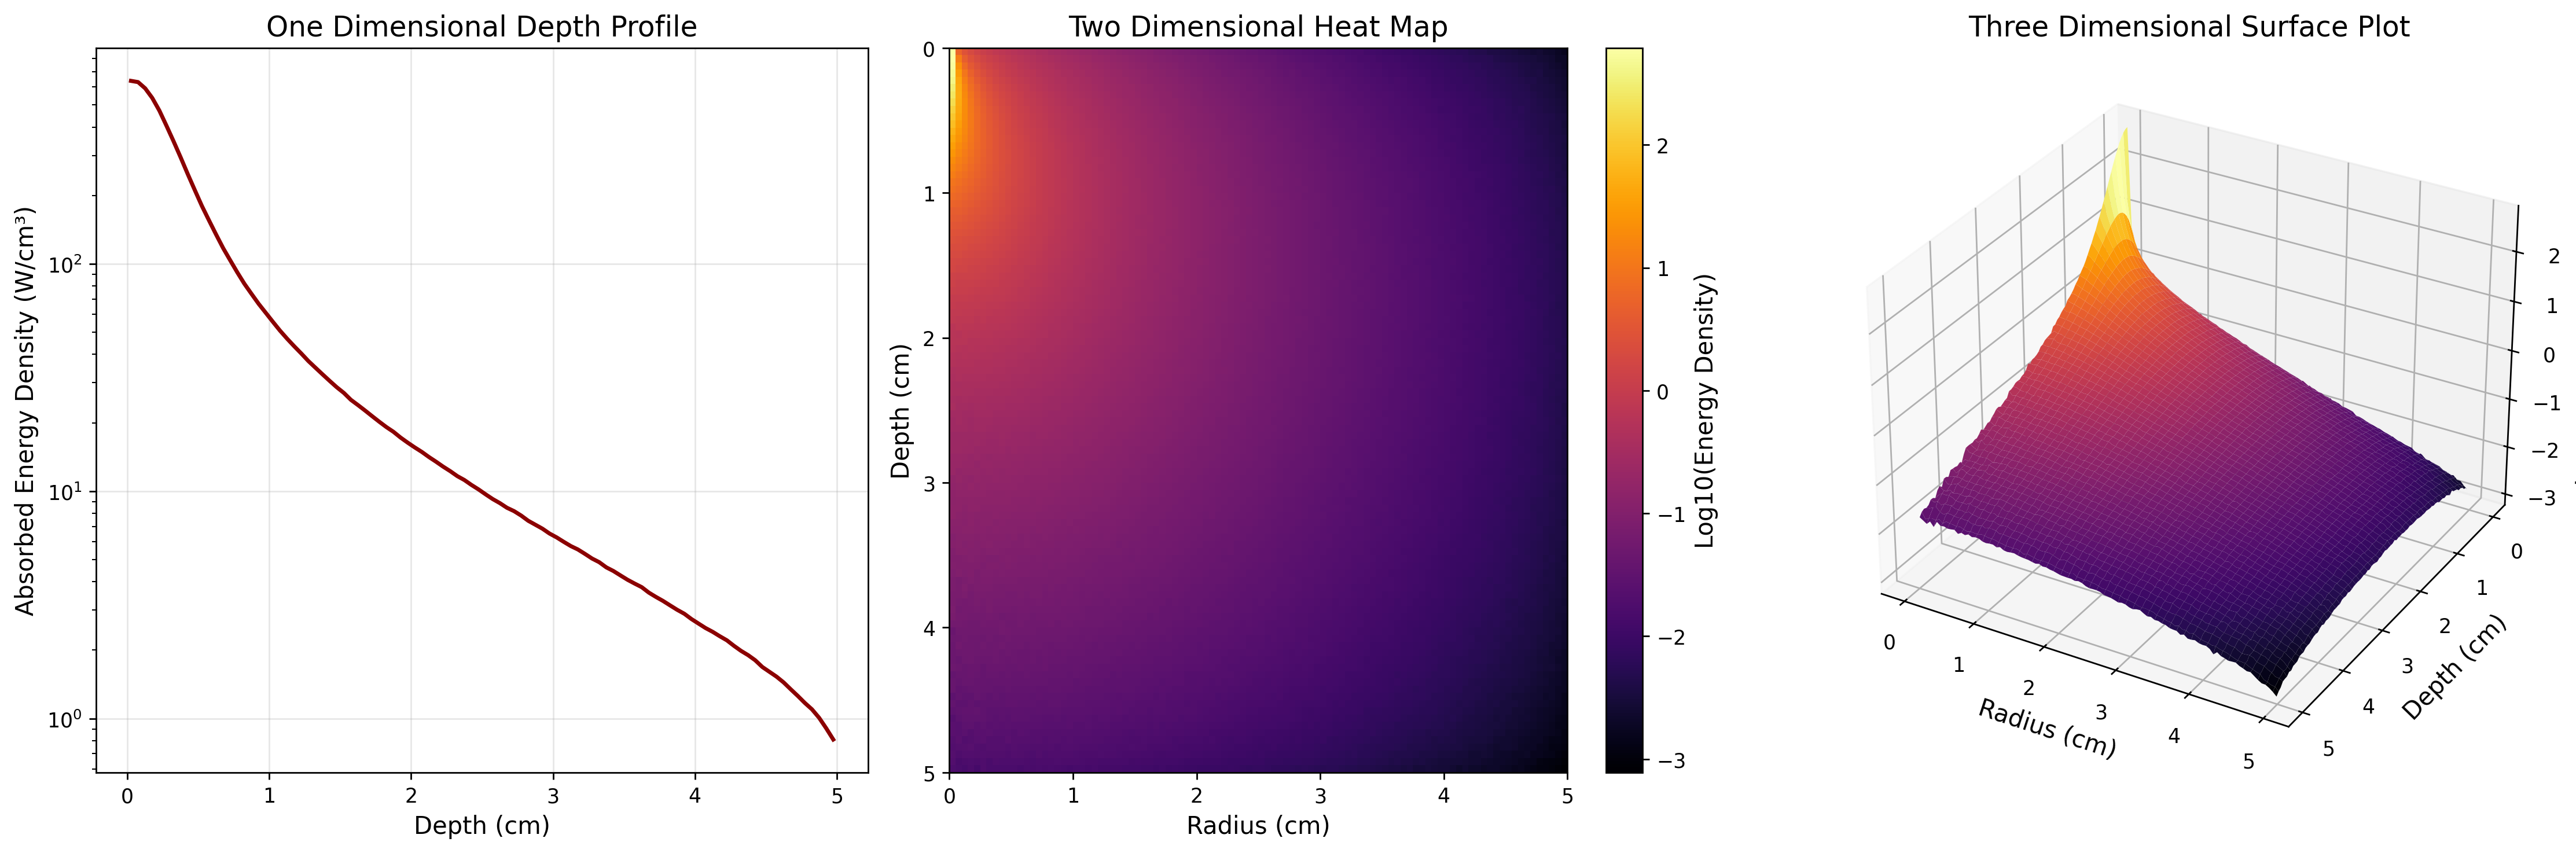

In [13]:
"""This script performs a graphics processing unit accelerated Monte Carlo simulation for transcranial photobiomodulation.

It utilizes CuPy to vectorize photon transport through biological tissue and
implements dimensionless photon weights to prevent premature loop termination.
"""

from typing import Tuple

import cupy as cp
import matplotlib.pyplot as plt
import numpy as np


# ============================================================================
# CONTROL KNOBS
# ============================================================================
INITIAL_POWER_WATTS = 47.0
WAVELENGTH_NM = 850.0
NUMBER_OF_PHOTONS = 1_000_000
MAXIMUM_DEPTH_CM = 5.0
MAXIMUM_RADIUS_CM = 5.0
GRID_RESOLUTION = 100

ABSORPTION_COEFFICIENT_CM_INV = 0.1   # mu_a
SCATTERING_COEFFICIENT_CM_INV = 10.0  # mu_s
ANISOTROPY_FACTOR = 0.9               # g
# ============================================================================


def simulate_photon_transport(
    power: float,
    mu_a: float,
    mu_s: float,
    g: float,
    num_photons: int,
    max_z: float,
    max_r: float,
    grid_size: int,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Simulates photon transport using stable vectorized graphics processing unit operations.

    Args:
        power: The initial source power in watts.
        mu_a: The absorption coefficient in inverse centimeters.
        mu_s: The scattering coefficient in inverse centimeters.
        g: The scattering anisotropy factor.
        num_photons: The total number of photon packets to simulate.
        max_z: The maximum depth for the simulation grid in centimeters.
        max_r: The maximum radius for the simulation grid in centimeters.
        grid_size: The number of bins along each spatial dimension.

    Returns:
        A tuple containing z_centers, r_centers, and absorption_grid as NumPy arrays.
    """
    mu_t = mu_a + mu_s
    albedo = mu_s / mu_t

    x = cp.zeros(num_photons)
    y = cp.zeros(num_photons)
    z = cp.zeros(num_photons)
    uz = cp.ones(num_photons)
    ux = cp.zeros(num_photons)
    uy = cp.zeros(num_photons)
    weights = cp.ones(num_photons)

    active = cp.ones(num_photons, dtype=bool)

    grid_elements = grid_size * grid_size
    absorption_grid_flat = cp.zeros(grid_elements)

    z_step = max_z / grid_size
    r_step = max_r / grid_size

    while cp.any(active):
        n_active = int(cp.sum(active).item())
        if n_active == 0:
            break

        rand_vals = cp.random.uniform(1e-14, 1.0, size=n_active)
        step_sizes = -cp.log(rand_vals) / mu_t

        x[active] += ux[active] * step_sizes
        y[active] += uy[active] * step_sizes
        z[active] += uz[active] * step_sizes

        radius = cp.sqrt(x**2 + y**2)
        out_of_bounds = (z >= max_z) | (z < 0) | (radius >= max_r)
        active &= ~out_of_bounds

        absorbed_weight = weights[active] * (1.0 - albedo)
        weights[active] -= absorbed_weight

        z_idx = (z[active] / z_step).astype(cp.int32)
        r_idx = (radius[active] / r_step).astype(cp.int32)

        z_idx = cp.clip(z_idx, 0, grid_size - 1)
        r_idx = cp.clip(r_idx, 0, grid_size - 1)

        flat_idx = z_idx * grid_size + r_idx

        # Utilize CuPy ufunc 'at' for safe in place summation on the device
        cp.add.at(absorption_grid_flat, flat_idx, absorbed_weight)

        active &= (weights > 1e-4)
        n_active_still = int(cp.sum(active).item())
        if n_active_still == 0:
            break

        rand_g = cp.random.rand(n_active_still)
        if g != 0:
            temp_factor = (1.0 - g**2) / (1.0 - g + 2.0 * g * rand_g)
            theta = cp.arccos(cp.clip((1.0 + g**2 - temp_factor**2) / (2.0 * g), -1.0, 1.0))
        else:
            theta = cp.arccos(2.0 * rand_g - 1.0)

        phi = 2.0 * cp.pi * cp.random.rand(n_active_still)

        sin_theta = cp.sin(theta)
        cos_theta = cp.cos(theta)
        sin_phi = cp.sin(phi)
        cos_phi = cp.cos(phi)

        curr_uz = uz[active]
        curr_ux = ux[active]
        curr_uy = uy[active]

        mask_near_pole = cp.abs(curr_uz) > 0.99999

        ux_new = cp.zeros(n_active_still)
        uy_new = cp.zeros(n_active_still)
        uz_new = cp.zeros(n_active_still)

        ux_new[mask_near_pole] = sin_theta[mask_near_pole] * cos_phi[mask_near_pole]
        uy_new[mask_near_pole] = sin_theta[mask_near_pole] * sin_phi[mask_near_pole]
        uz_new[mask_near_pole] = cp.sign(curr_uz[mask_near_pole]) * cos_theta[mask_near_pole]

        not_pole = ~mask_near_pole
        temp = cp.sqrt(1.0 - curr_uz[not_pole]**2)
        ux_new[not_pole] = (sin_theta[not_pole] * (curr_ux[not_pole] * curr_uz[not_pole] * cos_phi[not_pole] - curr_uy[not_pole] * sin_phi[not_pole]) /
                            temp + curr_ux[not_pole] * cos_theta[not_pole])
        uy_new[not_pole] = (sin_theta[not_pole] * (curr_uy[not_pole] * curr_uz[not_pole] * cos_phi[not_pole] + curr_ux[not_pole] * sin_phi[not_pole]) /
                            temp + curr_uy[not_pole] * cos_theta[not_pole])
        uz_new[not_pole] = -sin_theta[not_pole] * cos_phi[not_pole] * temp + curr_uz[not_pole] * cos_theta[not_pole]

        ux[active] = ux_new
        uy[active] = uy_new
        uz[active] = uz_new

    absorption_grid = absorption_grid_flat.reshape((grid_size, grid_size))

    absorption_grid *= (power / num_photons)

    z_edges = cp.linspace(0, max_z, grid_size + 1)
    r_edges = cp.linspace(0, max_r, grid_size + 1)

    r_diff_sq = cp.pi * (r_edges[1:]**2 - r_edges[:-1]**2)
    z_diff = z_edges[1:] - z_edges[:-1]

    volume_grid = cp.outer(z_diff, r_diff_sq)
    absorption_grid /= volume_grid

    z_centers = ((z_edges[:-1] + z_edges[1:]) / 2.0).get()
    r_centers = ((r_edges[:-1] + r_edges[1:]) / 2.0).get()
    final_grid = absorption_grid.get()

    return z_centers, r_centers, final_grid


def generate_visualizations(
    z_centers: np.ndarray,
    r_centers: np.ndarray,
    absorption_grid: np.ndarray,
) -> None:
    """Generates and displays high resolution simulation plots inline.

    Args:
        z_centers: Array of depth coordinates.
        r_centers: Array of radial coordinates.
        absorption_grid: Two dimensional array of absorbed energy density.
    """
    plt.rcParams.update({
        'font.sans-serif': ['Tahoma', 'DejaVu Sans'],
        'font.weight': 'normal',
        'figure.dpi': 250,
        'axes.titlesize': 14,
        'axes.labelsize': 12
    })

    depth_profile = np.sum(absorption_grid, axis=1)
    figure = plt.figure(figsize=(18, 6))

    ax1 = figure.add_subplot(131)
    ax1.plot(z_centers, depth_profile, color='darkred', linewidth=2)
    ax1.set_yscale('log')
    ax1.set_xlabel('Depth (cm)')
    ax1.set_ylabel('Absorbed Energy Density (W/cm³)')
    ax1.set_title('One Dimensional Depth Profile')
    ax1.grid(True, alpha=0.3)

    ax2 = figure.add_subplot(132)
    r_grid, z_grid = np.meshgrid(r_centers, z_centers)
    mesh = ax2.pcolormesh(r_grid, z_grid, np.log10(absorption_grid + 1e-10),
                          cmap='inferno', shading='auto')
    ax2.invert_yaxis()
    ax2.set_xlabel('Radius (cm)')
    ax2.set_ylabel('Depth (cm)')
    ax2.set_title('Two Dimensional Heat Map')
    figure.colorbar(mesh, ax=ax2, label='Log10(Energy Density)')

    ax3 = figure.add_subplot(133, projection='3d')
    ax3.plot_surface(r_grid, z_grid, np.log10(absorption_grid + 1e-10),
                     cmap='inferno', edgecolor='none')
    ax3.set_xlabel('Radius (cm)')
    ax3.set_ylabel('Depth (cm)')
    ax3.set_zlabel('Log10(Energy Density)')
    ax3.set_title('Three Dimensional Surface Plot')
    ax3.invert_yaxis()

    plt.tight_layout()
    plt.show()


if __name__ == '__main__':
    z_array, r_array, energy_matrix = simulate_photon_transport(
        power=INITIAL_POWER_WATTS,
        mu_a=ABSORPTION_COEFFICIENT_CM_INV,
        mu_s=SCATTERING_COEFFICIENT_CM_INV,
        g=ANISOTROPY_FACTOR,
        num_photons=NUMBER_OF_PHOTONS,
        max_z=MAXIMUM_DEPTH_CM,
        max_r=MAXIMUM_RADIUS_CM,
        grid_size=GRID_RESOLUTION,
    )

    generate_visualizations(z_array, r_array, energy_matrix)